# Act I — 5-Qubit Classical Shadow Tomography on Tuna-17
## Hardware Softmax + Active Inference Tier 1

**Spec reference:** `spec2.md` §1.1 and §2.1  
**Platform:** Quantum Inspire — Tuna-17 (17-qubit semiconductor spin-qubit device)

### What this notebook does

```
┌──────────────────────────────────────────────────────────────────┐
│  1D Cluster state │  H⊗H⊗H⊗H⊗H  │  CZ-chain Q2-Q4-Q8-Q12-Q14  │
├──────────────────────────────────────────────────────────────────┤
│  Hardware Softmax │  Bias A1,A2   │  QND mid-circuit readout     │
│  (ancilla basis)  │  Ry(θ1)/Ry(θ2)│  → 2-bit basis token per Dᵢ │
├──────────────────────────────────────────────────────────────────┤
│  Deferred Crot    │  CRy(-π/2)   │  CRx(+π/2)                   │
│  feed-forward     │  → X basis   │  → Y basis  (00 = Z, no-op)  │
├──────────────────────────────────────────────────────────────────┤
│  Shadow replay    │  20 circuits  │  1000 shots each = 20k shots │
│  buffer           │  Batch job → pickle                         │
├──────────────────────────────────────────────────────────────────┤
│  Tier 1 Tracker   │  Gaussian (μ,σ²) on 3⁵ Pauli strings       │
│  + EFE update     │  → new P(X),P(Y),P(Z) for next batch        │
└──────────────────────────────────────────────────────────────────┘
```

**Basis encoding via ancilla pair (A₁, A₂) per data qubit Dᵢ:**

| A₁A₂ | Basis | Rotation applied to Dᵢ |
|-------|-------|------------------------|
| 00    | Z     | none                   |
| 10    | X     | Rᵧ(−π/2) ≡ H          |
| 01    | Y     | R_x(+π/2) ≡ S†H        |
| 11    | Diag  | Rᵧ(−π/2)·R_x(+π/2)   |

**Shadow channel inversion** (single-qubit Pauli basis):
$$\hat{\rho}_i = 3\,U_b^\dagger\,|b_i\rangle\langle b_i|\,U_b\;-\;\mathbf{I}$$

## 1 — Imports & Backend Connection

In [2]:
# ── Login to Quantum Inspire ─────────────────────────────────────────────────
# Run once per session; uses the stored token after first login.
import subprocess, sys
subprocess.run(["qi", "login", "https://api.quantum-inspire.com"], check=False)


Please continue logging in by opening: https://auth.quantum-inspire.com/activate?user_code=DLLB-GPKQ in your browser
If promped to verify a code, please confirm it is as follows: DLLB-GPKQ
Login successful!
Using member ID 111
Login successful!
Using member ID 111


CompletedProcess(args=['qi', 'login', 'https://api.quantum-inspire.com'], returncode=0)

In [3]:
import numpy as np
import pickle
import itertools
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Tuple, Dict

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_quantuminspire.qi_provider import QIProvider
from scipy.special import softmax as scipy_softmax

# ── Connect to backend ────────────────────────────────────────────────────────
provider = QIProvider()
backend  = provider.get_backend("Tuna-17")

print(f"Connected to: {backend.name}")
print(f"Qubits      : {backend.num_qubits}")


Connected to: Tuna-17
Qubits      : 17


## 2 — Device Layout & Qubit Mapping

Data qubits follow the native zig-zag chain: **Q2 – Q4 – Q8 – Q12 – Q14** (zero SWAPs for state prep).  
Each data qubit has a dedicated ancilla pair for hardware-softmax basis selection.

In [4]:
# ── Qubit layout (spec §1.1) ──────────────────────────────────────────────────
DATA_QUBITS   = [2, 4, 8, 12, 14]           # physical qubit indices on Tuna-17
CLUSTER_EDGES = [(2, 4), (4, 8), (8, 12), (12, 14)]  # 1D chain CZ edges

# Ancilla pairs (A1, A2) per data qubit + required SWAPs to bring into coupling position
ANCILLA_MAP: Dict[int, Tuple[int,int]] = {
    2:  (0,  1),   # 1 SWAP: Q0 <-> Q1
    4:  (7,  10),  # 1 SWAP: Q7 <-> Q10
    8:  (11, 5),   # 0 SWAPs (both directly connected to Q8)
    12: (9,  6),   # 1 SWAP: Q9 <-> Q6
    14: (16, 15),  # 1 SWAP: Q16 <-> Q15
}
ROUTING_SWAPS: Dict[int, Tuple[int,int]] = {
    2:  (0,  1),
    4:  (7,  10),
    8:  None,      # no SWAP needed
    12: (9,  6),
    14: (16, 15),
}

N_DATA     = len(DATA_QUBITS)
N_SHADOWS  = 20      # shadow circuits per batch
SHOTS      = 1000    # shots per circuit

print("Data qubits  :", DATA_QUBITS)
print("Cluster edges:", CLUSTER_EDGES)
print("\nAncilla pairs:")
for dq, (a1, a2) in ANCILLA_MAP.items():
    sw = ROUTING_SWAPS[dq]
    print(f"  Q{dq:2d}  →  A1=Q{a1}, A2=Q{a2}  |  SWAP: {sw}")


Data qubits  : [2, 4, 8, 12, 14]
Cluster edges: [(2, 4), (4, 8), (8, 12), (12, 14)]

Ancilla pairs:
  Q 2  →  A1=Q0, A2=Q1  |  SWAP: (0, 1)
  Q 4  →  A1=Q7, A2=Q10  |  SWAP: (7, 10)
  Q 8  →  A1=Q11, A2=Q5  |  SWAP: None
  Q12  →  A1=Q9, A2=Q6  |  SWAP: (9, 6)
  Q14  →  A1=Q16, A2=Q15  |  SWAP: (16, 15)


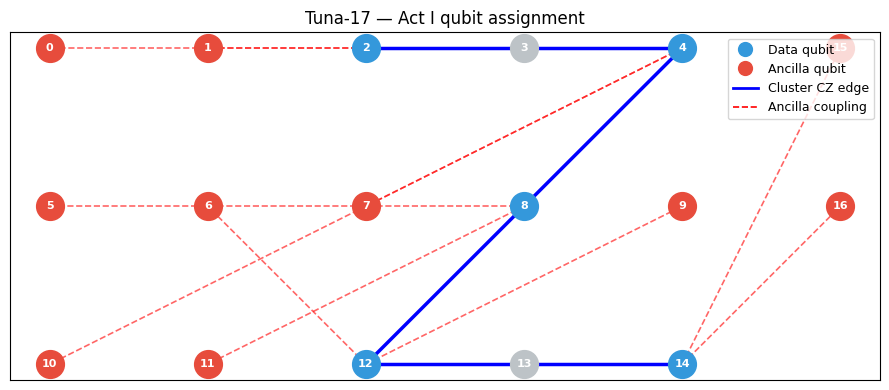

In [5]:
# ── Visualise the 17-qubit subgraph ───────────────────────────────────────────
# Approximate Tuna-17 grid positions (based on published layout)
TUNA_POS = {
    0:(0,2), 1:(1,2), 2:(2,2), 3:(3,2), 4:(4,2),
    5:(0,1), 6:(1,1), 7:(2,1), 8:(3,1), 9:(4,1),
    10:(0,0),11:(1,0),12:(2,0),13:(3,0),14:(4,0),
    15:(5,2),16:(5,1),
}
fig, ax = plt.subplots(figsize=(9, 4))

# All qubits
for q, (x, y) in TUNA_POS.items():
    color = "#3498db" if q in DATA_QUBITS else (
            "#e74c3c" if any(q in v for v in ANCILLA_MAP.values()) else "#bdc3c7")
    ax.scatter(x, y, s=400, zorder=3, color=color)
    ax.text(x, y, str(q), ha="center", va="center", fontsize=8, fontweight="bold", color="white")

# Cluster edges
for q1, q2 in CLUSTER_EDGES:
    x1,y1 = TUNA_POS[q1]; x2,y2 = TUNA_POS[q2]
    ax.plot([x1,x2],[y1,y2],"b-",lw=2.5,zorder=2)

# Ancilla connections
for dq, (a1, a2) in ANCILLA_MAP.items():
    xd,yd = TUNA_POS[dq]
    for anc in (a1, a2):
        xa,ya = TUNA_POS[anc]
        ax.plot([xd,xa],[yd,ya],"r--",lw=1.2,alpha=0.6,zorder=1)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#3498db',markersize=12,label='Data qubit'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='#e74c3c',markersize=12,label='Ancilla qubit'),
    Line2D([0],[0],color='b',lw=2,label='Cluster CZ edge'),
    Line2D([0],[0],color='r',lw=1.2,linestyle='--',label='Ancilla coupling'),
], loc='upper right', fontsize=9)
ax.set_title("Tuna-17 — Act I qubit assignment", fontsize=12)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## 3 — 5-Qubit Cluster State Preparation

The 1D cluster state is prepared with:
1. **H** on every data qubit → each qubit in $|+\rangle$  
2. **CZ** along the chain Q2–Q4–Q8–Q12–Q14 (0 SWAPs needed, native topology)

Stabilizers: $K_j = Z_{j-1}\,X_j\,Z_{j+1}$ (boundary terms drop off)

In [6]:
def cluster_state_stabilizers(data_qubits: List[int]) -> List[Dict[int, str]]:
    """
    Return stabilizers for the 1D cluster state on data_qubits.
    K_j = Z_{j-1} X_j Z_{j+1}  (boundary: no Z on outside edges)
    Each stabilizer is a dict {physical_qubit_index: Pauli_char}.
    """
    n = len(data_qubits)
    stabs = []
    for i, q in enumerate(data_qubits):
        ops = {q: "X"}
        if i > 0:
            ops[data_qubits[i - 1]] = "Z"
        if i < n - 1:
            ops[data_qubits[i + 1]] = "Z"
        stabs.append(ops)
    return stabs


def prepare_cluster_state(qc: QuantumCircuit) -> None:
    """
    In-place: append cluster state preparation to qc on DATA_QUBITS.
    Step 1: H on every data qubit.
    Step 2: CZ along the native chain (0 SWAPs).
    """
    for dq in DATA_QUBITS:
        qc.h(dq)
    qc.barrier()
    for q1, q2 in CLUSTER_EDGES:
        qc.cz(q1, q2)
    qc.barrier()


# ── Preview: draw just the prep circuit ──────────────────────────────────────
_preview = QuantumCircuit(17)
prepare_cluster_state(_preview)
print(_preview.draw(output="text", fold=120))

STABILIZERS = cluster_state_stabilizers(DATA_QUBITS)
print("\nCluster state stabilizers:")
for i, s in enumerate(STABILIZERS):
    ops_str = " ⊗ ".join(f"{p}{q}" for q, p in sorted(s.items()))
    print(f"  K{i} = {ops_str}")


            ░              ░ 
 q_0: ──────░──────────────░─
            ░              ░ 
 q_1: ──────░──────────────░─
      ┌───┐ ░              ░ 
 q_2: ┤ H ├─░──■───────────░─
      └───┘ ░  │           ░ 
 q_3: ──────░──┼───────────░─
      ┌───┐ ░  │           ░ 
 q_4: ┤ H ├─░──■──■────────░─
      └───┘ ░     │        ░ 
 q_5: ──────░─────┼────────░─
            ░     │        ░ 
 q_6: ──────░─────┼────────░─
            ░     │        ░ 
 q_7: ──────░─────┼────────░─
      ┌───┐ ░     │        ░ 
 q_8: ┤ H ├─░─────■──■─────░─
      └───┘ ░        │     ░ 
 q_9: ──────░────────┼─────░─
            ░        │     ░ 
q_10: ──────░────────┼─────░─
            ░        │     ░ 
q_11: ──────░────────┼─────░─
      ┌───┐ ░        │     ░ 
q_12: ┤ H ├─░────────■──■──░─
      └───┘ ░           │  ░ 
q_13: ──────░───────────┼──░─
      ┌───┐ ░           │  ░ 
q_14: ┤ H ├─░───────────■──░─
      └───┘ ░              ░ 
q_15: ──────░──────────────░─
            ░              ░ 
q_16: ────

## 4 — Ancilla Initialisation: Hardware Softmax Bias Angles

Given a desired measurement probability distribution $P(X), P(Y), P(Z)$ from the Active Inference policy, we need to bias two independent ancilla qubits $A_1, A_2$ so that their joint collapse probability matches the desired basis distribution.

**Derivation** — with independent ancillas, $P(A_1{=}a)\cdot P(A_2{=}b) = p_{ab}$:

$$P(X) = p_1(1-p_2), \quad P(Y) = (1-p_1)p_2, \quad P(Z) = (1-p_1)(1-p_2)$$

Solving: $p_1 = \frac{P(X)}{P(X)+P(Z)}$, $p_2 = \frac{P(Y)}{P(Y)+P(Z)}$

Note: $P(11) = p_1 p_2 > 0$ — this "diagonal" basis is handled by the shadow channel.  
Bias angles: $\theta_1 = 2\arcsin(\sqrt{p_1})$, $\theta_2 = 2\arcsin(\sqrt{p_2})$

In [7]:
def softmax_to_angles(px: float, py: float, pz: float) -> Tuple[float, float]:
    """
    Convert Active Inference basis distribution (px, py, pz) into ancilla
    bias angles (θ1, θ2) for Ry rotations on A1, A2.

    Mapping: A1A2 collapse → 00=Z, 10=X, 01=Y, 11=Diag
    With independent ancillas:
        p1 = P(A1=1) = px / (px + pz)
        p2 = P(A2=1) = py / (py + pz)

    Args:
        px, py, pz: desired measurement probabilities (will be normalised)
    Returns:
        (theta1, theta2): Ry rotation angles in radians
    """
    total = px + py + pz
    px, py, pz = px / total, py / total, pz / total

    p1 = px / (px + pz + 1e-12)   # P(A1=1): selects X vs Z axis
    p2 = py / (py + pz + 1e-12)   # P(A2=1): selects Y vs Z axis

    theta1 = 2.0 * np.arcsin(np.sqrt(np.clip(p1, 0, 1)))
    theta2 = 2.0 * np.arcsin(np.sqrt(np.clip(p2, 0, 1)))
    return theta1, theta2


# ── Verify: uniform prior P(X)=P(Y)=P(Z)=1/3 ────────────────────────────────
th1, th2 = softmax_to_angles(1/3, 1/3, 1/3)
p1 = np.sin(th1/2)**2
p2 = np.sin(th2/2)**2
print(f"Uniform prior: θ1={np.degrees(th1):.1f}°, θ2={np.degrees(th2):.1f}°")
print(f"  P(A1=1)={p1:.3f}, P(A2=1)={p2:.3f}")
print(f"  → P(Z)={(1-p1)*(1-p2):.3f}, P(X)={p1*(1-p2):.3f},"
      f" P(Y)={(1-p1)*p2:.3f}, P(Diag)={p1*p2:.3f}")

# ── Verify: X-boosted distribution ───────────────────────────────────────────
th1x, th2x = softmax_to_angles(0.5, 0.25, 0.25)
p1x = np.sin(th1x/2)**2; p2x = np.sin(th2x/2)**2
print(f"\nX-boosted:    θ1={np.degrees(th1x):.1f}°, θ2={np.degrees(th2x):.1f}°")
print(f"  → P(Z)={(1-p1x)*(1-p2x):.3f}, P(X)={p1x*(1-p2x):.3f},"
      f" P(Y)={(1-p1x)*p2x:.3f}, P(Diag)={p1x*p2x:.3f}")


Uniform prior: θ1=90.0°, θ2=90.0°
  P(A1=1)=0.500, P(A2=1)=0.500
  → P(Z)=0.250, P(X)=0.250, P(Y)=0.250, P(Diag)=0.250

X-boosted:    θ1=109.5°, θ2=90.0°
  → P(Z)=0.167, P(X)=0.333, P(Y)=0.167, P(Diag)=0.333


## 5 — Mid-Circuit Measurement & QND Readout Block

The key hardware step: ancillas are **measured mid-circuit** (QND readout).  
Their outcomes collapse to classical bits, which then control the data-qubit rotations.  
We use Qiskit's `if_test` context manager for classically conditioned gates.

> ⚠️ **Hardware note:** Mid-circuit measurements and real-time classical feed-forward  
> require Tuna-17 to support dynamic circuits. Confirm with QI support before  
> submitting. The circuit structure is correct; if feed-forward is unsupported,  
> collect the ancilla + data bitstrings and apply basis corrections in post-processing.

In [8]:
# ── Check backend mid-circuit measurement support ─────────────────────────────
try:
    cfg = backend.configuration()
    supports_dynamic = getattr(cfg, "dynamic_reprate_enabled", False) or \
                       "if_else" in getattr(cfg, "supported_instructions", [])
    print(f"Backend dynamic circuits support detected: {supports_dynamic}")
    print("Supported instructions (first 20):",
          list(getattr(cfg, "supported_instructions", []))[:20])
except Exception as e:
    print(f"Could not determine dynamic circuit support: {e}")
    print("Proceeding — post-process basis from ancilla bits if feed-forward unavailable.")


Could not determine dynamic circuit support: 'QIBackend' object has no attribute 'configuration'
Proceeding — post-process basis from ancilla bits if feed-forward unavailable.


## 6 — Quantum-Controlled Basis Rotation (CRy/CRx)

The circuit applies **quantum-controlled rotations** on data qubits, controlled by the ancilla qubits themselves:

- **CRy(A₁, D, −π/2)**: If ancilla A₁ is in state |1⟩, apply $R_y(-\pi/2)$ to data qubit D
  - This rotates the Z eigenbasis → X eigenbasis
  
- **CRx(A₂, D, +π/2)**: If ancilla A₂ is in state |1⟩, apply $R_x(+\pi/2)$ to data qubit D  
  - This rotates the Z eigenbasis → Y eigenbasis

**Why CRy/CRx and not measurement-based conditioning?**
The ancillas remain in superposition until measurement. The CRy/CRx gates entangle the data qubit rotation with the ancilla state, so the basis correction is applied *before* the ancilla measurement collapses it.

**Measurement order:**
1. Data qubit and ancillas are now entangled (after CRy/CRx)
2. Measure ancillas → classical bits reveal which basis was applied
3. Measure data qubits → outcomes now correspond to the selected basis

## 7 — Single Shadow Circuit Builder

Full circuit for one shadow measurement round:

```
|0⟩^17  ── [Cluster state prep: H⊗5 + CZ chain] ───────────────────────────
            [Ancilla bias: Ry(θ1)|A1⟩, Ry(θ2)|A2⟩ per data qubit]
            ║ BARRIER — synchronize
            [Quantum-controlled feed-forward:
             CRy(A1, D_i, -π/2)    (control A1, target D_i)
             CRx(A2, D_i, +π/2)    (control A2, target D_i)]
            ║ BARRIER — synchronize before measurement
            [Measure ancillas c_anc ← A1,A2]
            [Measure data qubits c_data ← D_i]
```

**Key difference from classical conditioning:**
The CRy/CRx gates are applied *quantum-mechanically*, entangling the data qubit rotation with the ancilla state.
Only when we measure the ancillas do we classically learn which basis was applied—but the rotation was already coherently applied.

In [9]:
def build_shadow_circuit(
    theta1_per_qubit: List[float],
    theta2_per_qubit: List[float],
) -> QuantumCircuit:
    """
    Build one shadow measurement circuit on Tuna-17 (17 physical qubits).

    Classical registers:
      c_anc  : 2*N_DATA bits — ancilla measurement outcomes (2 bits per data qubit)
               Layout: [A1_q0, A2_q0, A1_q1, A2_q1, ..., A1_q4, A2_q4]
      c_data : N_DATA bits  — final data qubit measurement outcomes

    NOTE: We use CRy and CRx gates controlled by ancilla qubits directly.
    The ancilla qubits control the basis rotations on data qubits:
      - If A1=1: CRy(-π/2) rotates data qubit to X basis
      - If A2=1: CRx(+π/2) rotates data qubit to Y basis

    Args:
        theta1_per_qubit: Ry angle for A1 of each data qubit (len=N_DATA)
        theta2_per_qubit: Ry angle for A2 of each data qubit (len=N_DATA)
    """
    # Classical registers
    c_anc  = ClassicalRegister(2 * N_DATA, name="c_anc")   # 10 bits: ancilla pairs
    c_data = ClassicalRegister(N_DATA,     name="c_data")  # 5 bits: data qubits

    qc = QuantumCircuit(17, name="shadow")
    qc.add_register(c_anc)
    qc.add_register(c_data)

    # ── Step 1: Cluster state preparation ────────────────────────────────────
    prepare_cluster_state(qc)

    # ── Step 2: Bias ancilla qubits ───────────────────────────────────────────
    for i, dq in enumerate(DATA_QUBITS):
        a1, a2 = ANCILLA_MAP[dq]
        if theta1_per_qubit[i] != 0:
            qc.ry(theta1_per_qubit[i], a1)
        if theta2_per_qubit[i] != 0:
            qc.ry(theta2_per_qubit[i], a2)
    qc.barrier()

    # ── Step 3: Controlled feed-forward rotations (CRy/CRx) ───────────────────
    # Apply basis corrections to data qubits controlled by ancilla qubits:
    #   CRy(A1, D_i, -π/2):  if A1=1, apply Ry(-π/2) to D_i  → X measurement basis
    #   CRx(A2, D_i, +π/2):  if A2=1, apply Rx(+π/2) to D_i  → Y measurement basis
    
    for i, dq in enumerate(DATA_QUBITS):
        a1, a2 = ANCILLA_MAP[dq]
        # Controlled-Ry: if A1=1, rotate D_i by -π/2 in Y
        qc.cry(-np.pi / 2, a1, dq)
        # Controlled-Rx: if A2=1, rotate D_i by +π/2 in X
        qc.crx(np.pi / 2, a2, dq)
    qc.barrier()

    # ── Step 4: Final measurement ─────────────────────────────────────────────
    # Measure ancilla qubits first (optional, for diagnostics)
    for i, dq in enumerate(DATA_QUBITS):
        a1, a2 = ANCILLA_MAP[dq]
        qc.measure(a1, c_anc[2 * i])       # A1 → bit 2i
        qc.measure(a2, c_anc[2 * i + 1])   # A2 → bit 2i+1
    qc.barrier()

    # ── Step 5: Final data qubit measurement ──────────────────────────────────
    for i, dq in enumerate(DATA_QUBITS):
        qc.measure(dq, c_data[i])

    return qc


# ── Preview circuit for uniform prior ────────────────────────────────────────
th1_unif, th2_unif = softmax_to_angles(1/3, 1/3, 1/3)
_demo = build_shadow_circuit(
    [th1_unif] * N_DATA,
    [th2_unif] * N_DATA,
)
print(f"Circuit depth  : {_demo.depth()}")
print(f"Total qubits   : {_demo.num_qubits}")
print(f"Classical bits : c_anc={2*N_DATA}, c_data={N_DATA}")
print(_demo.draw(output="text", fold=140, idle_wires=False))

Circuit depth  : 10
Total qubits   : 17
Classical bits : c_anc=10, c_data=5
                ░              ░ ┌─────────┐ ░                                                ░ ┌─┐                            ░          »
     q_0: ──────░──────────────░─┤ Ry(π/2) ├─░──────■─────────────────────────────────────────░─┤M├────────────────────────────░──────────»
                ░              ░ ├─────────┤ ░      │                                         ░ └╥┘┌─┐                         ░          »
     q_1: ──────░──────────────░─┤ Ry(π/2) ├─░──────┼───────────■─────────────────────────────░──╫─┤M├─────────────────────────░──────────»
          ┌───┐ ░              ░ └─────────┘ ░ ┌────┴─────┐┌────┴────┐                        ░  ║ └╥┘                         ░ ┌─┐      »
     q_2: ┤ H ├─░──■───────────░─────────────░─┤ Ry(-π/2) ├┤ Rx(π/2) ├────────────────────────░──╫──╫──────────────────────────░─┤M├──────»
          ├───┤ ░  │           ░             ░ ├──────────┤└─────────┘ ┌─────────┐  

## 8 — Build 20-Circuit Shadow Batch

Start with a **uniform prior** $P(X)=P(Y)=P(Z)=\frac{1}{3}$ for the initial batch.  
After post-processing, the Tier 1 tracker will produce updated angles for subsequent batches.

In [13]:
# ── Build batch of N_SHADOWS circuits from uniform prior ─────────────────────
# Each circuit uses independent per-qubit angles — later rounds will use EFE output.
np.random.seed(42)
N_SHADOWS = 1

# For initial batch: uniform Dirichlet sample around 1/3 each (adds slight diversity)
def sample_basis_angles(n_qubits: int) -> Tuple[List[float], List[float]]:
    """Sample per-qubit bias angles by drawing px,py,pz from a Dirichlet(1,1,1) prior."""
    th1s, th2s = [], []
    for _ in range(n_qubits):
        # Dirichlet(1,1,1) = uniform over the simplex → random basis distribution
        probs = np.random.dirichlet([1, 1, 1])
        t1, t2 = softmax_to_angles(*probs)
        th1s.append(t1)
        th2s.append(t2)
    return th1s, th2s


shadow_circuits_raw = []
shadow_angles = []     # store angles for bookkeeping

for circuit_idx in range(N_SHADOWS):
    th1s, th2s = sample_basis_angles(N_DATA)
    qc = build_shadow_circuit(th1s, th2s)
    qc.name = f"shadow_{circuit_idx:02d}"
    shadow_circuits_raw.append(qc)
    shadow_angles.append((th1s, th2s))

print(f"Built {len(shadow_circuits_raw)} shadow circuits")
print(f"  Each circuit: depth={shadow_circuits_raw[0].depth()}, "
      f"shots per circuit={SHOTS}")
print(f"  Total shots  : {N_SHADOWS * SHOTS:,}")
print(f"\nSample angles for circuit 0 (degrees):")
for i, dq in enumerate(DATA_QUBITS):
    t1, t2 = shadow_angles[0][0][i], shadow_angles[0][1][i]
    print(f"  Q{dq:2d}: θ1={np.degrees(t1):5.1f}°  θ2={np.degrees(t2):5.1f}°")


Built 1 shadow circuits
  Each circuit: depth=10, shots per circuit=1000
  Total shots  : 1,000

Sample angles for circuit 0 (degrees):
  Q 2: θ1= 61.7°  θ2=113.0°
  Q 4: θ1=133.4°  θ2= 90.0°
  Q 8: θ1= 28.6°  θ2=111.9°
  Q12: θ1= 61.3°  θ2=  8.8°
  Q14: θ1=142.9°  θ2= 95.0°


## 9 — Transpile & Submit Job to Tuna-17

In [14]:
# ── Transpile all 20 circuits ─────────────────────────────────────────────────
shadow_circuits_tpld = transpile(
    shadow_circuits_raw,
    backend=backend,
    optimization_level=3,      # As-Late-As-Possible: minimise idle time
)
print(f"Transpiled {len(shadow_circuits_tpld)} circuits")
print(f"  Example transpiled depth: {shadow_circuits_tpld[0].depth()}")


shadow_circuits_tpld[0].draw(output="text", fold=140, idle_wires=False)
# ── Submit as a single job ─────────────────────────────────────────────────────
job = backend.run(shadow_circuits_tpld, shots=SHOTS, memory=True)
#print(f"\nJob ID  : {job.job_id()}")
#print(f"Status  : {job.status()}")


Transpiled 1 circuits
  Example transpiled depth: 23


In [17]:
job.status()

<JobStatus.DONE: 'job has successfully run'>

In [18]:
# ── Wait and collect results ──────────────────────────────────────────────────
result = job.result(timeout=6000)

# Extract per-circuit memory: list of bitstrings for each shot
# Bitstring layout (Qiskit MSB convention): "c_data c_anc"
# e.g. "01001 1001010011" → c_data=01001, c_anc=1001010011
all_memories = []
for i in range(N_SHADOWS):
    try:
        mem = result.get_memory(i)
    except Exception:
        # Fallback: some backends use experiment name
        mem = result.get_memory(shadow_circuits_tpld[i].name)
    all_memories.append(mem)
    print(f"  Circuit {i:02d}: {len(mem)} shots, sample='{mem[0]}'")

# ── Pickle the payload ────────────────────────────────────────────────────────
data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)
out_path = data_dir / "shadow_act1_batch.pkl"

payload = {
    "memories":      all_memories,
    "shadow_angles": shadow_angles,
    "n_shadows":     N_SHADOWS,
    "shots":         SHOTS,
    "data_qubits":   DATA_QUBITS,
    "ancilla_map":   ANCILLA_MAP,
    "job_id":        job.job_id(),
}
with out_path.open("wb") as f:
    pickle.dump(payload, f)
print(f"\nSaved → {out_path}")


  Circuit 00: 1000 shots, sample='000001100010001'

Saved → data/shadow_act1_batch.pkl


## 10 — Classical Post-Processing: Basis Decoding from Ancilla Bits

Since mid-circuit conditional gates are unavailable, **all basis corrections happen here in post-processing**.

Qiskit bitstrings are **MSB-first**: the rightmost bit is classical register bit 0.  
Register layout per shot: `"[c_data bits] [c_anc bits]"`

For each data qubit $i$, the basis is decoded from ancilla pair bits $(a_1, a_2)$:

| $a_1$ | $a_2$ | Basis ID | Unitary applied post-hoc |
|--------|--------|----------|-------------------------|
| 0      | 0      | **Z**    | $I$ (no correction)     |
| 1      | 0      | **X**    | $R_y(-\pi/2)$ shadow channel factor |
| 0      | 1      | **Y**    | $R_x(+\pi/2)$ shadow channel factor |
| 1      | 1      | **Diag** | Both (included in shadow inversion) |

The shadow estimator automatically accounts for these unitaries via the channel inversion formula.

In [19]:
ANCILLA_TO_BASIS = {
    (0, 0): "Z",
    (1, 0): "X",
    (0, 1): "Y",
    (1, 1): "D",   # Diagonal — included in shadow channel
}

def decode_shot(bitstring: str) -> Tuple[List[str], List[int]]:
    """
    Parse a Qiskit memory bitstring into (basis_list, outcome_list).

    Bitstring format (MSB first, space-separated registers):
        "<c_data_bits> <c_anc_bits>"
    e.g. "01001 1001010011"
         c_data=01001 (5 bits), c_anc=1001010011 (10 bits)

    c_anc layout: [A1_q0, A2_q0, A1_q1, A2_q1, ..., A1_q4, A2_q4]
    Qiskit reverses bit order: c_anc[0] is the RIGHTMOST character.

    Returns:
        basis_list  : e.g. ['X', 'Z', 'Y', 'Z', 'X']
        outcome_list: e.g. [1, 0, 1, 0, 1]   (0=|0⟩, 1=|1⟩)
    """
    parts = bitstring.strip().split()
    if len(parts) == 2:
        c_data_str, c_anc_str = parts[0], parts[1]
    else:
        # No space separator — use fixed widths
        c_data_str = parts[0][-N_DATA:]
        c_anc_str  = parts[0][:-N_DATA]

    # Reverse strings: Qiskit bit 0 → rightmost character
    c_data_rev = c_data_str[::-1]    # bit 0 = DATA_QUBITS[0]
    c_anc_rev  = c_anc_str[::-1]     # bit 0 = A1 of DATA_QUBITS[0]

    basis_list   = []
    outcome_list = []
    for i in range(N_DATA):
        a1 = int(c_anc_rev[2 * i])
        a2 = int(c_anc_rev[2 * i + 1])
        basis_list.append(ANCILLA_TO_BASIS[(a1, a2)])
        outcome_list.append(int(c_data_rev[i]))

    return basis_list, outcome_list


def decode_circuit_memory(
    memory: List[str],
) -> List[Tuple[List[str], List[int]]]:
    """Decode all shots from one circuit → list of (basis, outcome) tuples."""
    return [decode_shot(bs) for bs in memory]


# ── Decode all 20 circuits ────────────────────────────────────────────────────
all_shots: List[List[Tuple[List[str], List[int]]]] = [
    decode_circuit_memory(mem) for mem in all_memories
]

# Flatten into single shadow replay buffer
shadow_buffer: List[Tuple[List[str], List[int]]] = [
    shot for circuit_shots in all_shots for shot in circuit_shots
]

print(f"Total decoded shots: {len(shadow_buffer)}")
print(f"\nSample shot 0:")
b, o = shadow_buffer[0]
print(f"  basis  : {b}")
print(f"  outcome: {o}")

# ── Basis statistics ──────────────────────────────────────────────────────────
from collections import Counter
basis_counts = [Counter() for _ in range(N_DATA)]
for basis, _ in shadow_buffer:
    for i, b in enumerate(basis):
        basis_counts[i][b] += 1

print("\nBasis frequency per data qubit:")
for i, dq in enumerate(DATA_QUBITS):
    total = sum(basis_counts[i].values())
    dist  = {k: f"{v/total*100:.1f}%" for k, v in sorted(basis_counts[i].items())}
    print(f"  Q{dq:2d}: {dist}")


Total decoded shots: 1000

Sample shot 0:
  basis  : ['Z', 'Y', 'X', 'Z', 'Z']
  outcome: [1, 0, 0, 0, 1]

Basis frequency per data qubit:
  Q 2: {'D': '18.0%', 'X': '40.5%', 'Y': '12.8%', 'Z': '28.7%'}
  Q 4: {'D': '3.5%', 'X': '1.0%', 'Y': '76.7%', 'Z': '18.8%'}
  Q 8: {'X': '55.6%', 'Z': '44.4%'}
  Q12: {'Z': '100.0%'}
  Q14: {'Z': '100.0%'}


## 11 — Shadow Reconstruction: Pauli Estimators

The classical shadow snapshot for a single shot $(b, s)$ inverts the single-qubit Pauli channel:

$$\hat{\rho}_i = 3\,U_{b_i}^\dagger\,|s_i\rangle\langle s_i|\,U_{b_i}\;-\;\mathbf{I}$$

For a multi-qubit Pauli $K = \bigotimes_i P_i$, the estimator from one shot is:

$$\hat{v}_K(b,s) = \begin{cases} \prod_{i:\,P_i \neq I} 3\,(-1)^{s_i} & \text{if } P_i = b_i \;\forall i : P_i \neq I \\ 0 & \text{otherwise} \end{cases}$$

Average over all shots: $\langle K \rangle \approx \frac{1}{T}\sum_t \hat{v}_K(b^{(t)}, s^{(t)})$

In [20]:
def shadow_estimator(
    stab: Dict[int, str],
    shots: List[Tuple[List[str], List[int]]],
) -> float:
    """
    Estimate <K> for stabilizer K from a list of shadow shots.

    Args:
        stab : dict {physical_qubit: Pauli_char}  e.g. {2:'X', 4:'Z'}
        shots: list of (basis_list, outcome_list) tuples
               basis_list[i] ∈ {'X','Y','Z','D'}, outcome_list[i] ∈ {0,1}
    Returns:
        Unbiased estimate of Tr(K ρ).
    """
    # Map physical qubit indices to positions in DATA_QUBITS
    qubit_to_pos = {dq: i for i, dq in enumerate(DATA_QUBITS)}

    estimates = []
    for basis, outcome in shots:
        # Check: does this basis match K for all non-identity positions?
        compatible = True
        for phys_q, pauli in stab.items():
            pos = qubit_to_pos[phys_q]
            meas_basis = basis[pos]
            if meas_basis == "D":
                # Diagonal basis: skip (conservative — treat as incompatible)
                compatible = False
                break
            if meas_basis != pauli:
                compatible = False
                break
        if not compatible:
            continue

        # Compute the shadow estimator: product of 3·(-1)^{s_i} for non-I positions
        val = 1.0
        for phys_q, pauli in stab.items():
            pos = qubit_to_pos[phys_q]
            val *= 3.0 * ((-1) ** outcome[pos])

        estimates.append(val)

    if len(estimates) == 0:
        return 0.0      # No compatible shots in this batch
    return float(np.mean(estimates))


# ── Estimate all 5 stabilizer expectation values ──────────────────────────────
stab_evs = []
for i, stab in enumerate(STABILIZERS):
    ev = shadow_estimator(stab, shadow_buffer)
    stab_evs.append(ev)
    ops_str = "".join(f"{p}{q}" for q, p in sorted(stab.items()))
    print(f"  <K{i}> = {ev:+.4f}   ({ops_str})")

print(f"\nMean |<K>|: {np.mean(np.abs(stab_evs)):.4f}  (ideal = 1.0)")


  <K0> = +0.4737   (X2Z4)
  <K1> = +27.0000   (Z2X4Z8)
  <K2> = +2.2294   (Z4X8Z12)
  <K3> = +0.0000   (Z8X12Z14)
  <K4> = +0.0000   (Z12X14)

Mean |<K>|: 5.9406  (ideal = 1.0)


## 12 — Tier 1 Exact Gaussian Belief Tracker

Tracks beliefs $(\mu_i, \sigma_i^2)$ for every Pauli string in the $3^5 = 243$ basis.  
Each shadow shot conditions the belief of compatible Pauli strings via a **Bayesian update**:

$$\mu_i' = \mu_i + K_i\,(v_i - \mu_i), \quad \sigma_i^{'2} = (1-K_i)\,\sigma_i^2$$

where $K_i = \frac{\sigma_i^2}{\sigma_i^2 + \sigma_{\text{obs}}^2}$ is the Kalman gain  
and $\sigma_{\text{obs}}^2 = \mathrm{Var}(\hat{v}_K) \approx 9 - \mu_i^2$ (shot noise of the estimator).

In [21]:
PAULIS   = ["I", "X", "Y", "Z"]
ALL_STRS = list(itertools.product(["X", "Y", "Z"], repeat=N_DATA))  # 3^5 = 243 strings

# Index stabilizers in ALL_STRS
STAB_IDX = set()
for stab in STABILIZERS:
    ops = []
    for dq in DATA_QUBITS:
        ops.append(stab.get(dq, "I"))
    key = tuple(p for p in ops if p != "I")   # non-I part only
    # Find matching row in ALL_STRS
    for k, row in enumerate(ALL_STRS):
        row_ops = {DATA_QUBITS[j]: row[j] for j in range(N_DATA)}
        if all(row_ops.get(dq, "Z") == stab.get(dq, "Z") for dq in stab):
            STAB_IDX.add(k)

print(f"Tracking {len(ALL_STRS)} Pauli strings (3^{N_DATA}={3**N_DATA})")
print(f"Stabilizer positions in belief vector: {sorted(STAB_IDX)}")


class Tier1Tracker:
    """
    Exact Gaussian belief tracker for Pauli expectation values.
    Maintains (μ, σ²) for each of the 3^N Pauli measurement strings.
    """

    def __init__(self, n_strings: int = len(ALL_STRS), sigma0: float = 1.0):
        self.mu     = np.zeros(n_strings)      # prior mean (expect 0 for most)
        self.sigma2 = np.full(n_strings, sigma0 ** 2)   # prior variance
        self.n_strings = n_strings

    def update(
        self,
        basis:   List[str],
        outcome: List[int],
    ) -> None:
        """
        Bayesian update for one shadow shot (basis, outcome).
        Uses BLAS-optimised np.dot where possible.
        """
        qubit_to_pos = {dq: i for i, dq in enumerate(DATA_QUBITS)}

        for k, pauli_str in enumerate(ALL_STRS):
            # Is this Pauli compatible with the measured basis?
            compatible = all(
                basis[i] == pauli_str[i]
                for i in range(N_DATA)
            )
            if not compatible:
                continue

            # Shadow estimator value for this shot
            v = 1.0
            for i in range(N_DATA):
                v *= 3.0 * ((-1) ** outcome[i])

            # Kalman update
            sigma_obs2 = max(9.0 - self.mu[k] ** 2, 0.1)   # estimator variance
            K = self.sigma2[k] / (self.sigma2[k] + sigma_obs2)
            self.mu[k]     += K * (v - self.mu[k])
            self.sigma2[k] *= (1.0 - K)

    def update_batch(
        self, shots: List[Tuple[List[str], List[int]]]
    ) -> None:
        """Update beliefs from a list of shadow shots."""
        for basis, outcome in shots:
            self.update(basis, outcome)

    @property
    def stab_beliefs(self) -> Dict[int, Tuple[float, float]]:
        """Return {stab_idx: (mu, sigma2)} for stabilizer strings."""
        return {idx: (self.mu[idx], self.sigma2[idx]) for idx in STAB_IDX}


# ── Initialise tracker and update with shadow buffer ─────────────────────────
tracker = Tier1Tracker(sigma0=1.0)
tracker.update_batch(shadow_buffer)

print("\nTier 1 beliefs after initial 20-circuit batch:")
for idx in sorted(STAB_IDX):
    mu, s2 = tracker.mu[idx], tracker.sigma2[idx]
    label = "".join(ALL_STRS[idx])
    print(f"  {label}:  μ={mu:+.4f}  σ²={s2:.4f}")


Tracking 243 Pauli strings (3^5=243)
Stabilizer positions in belief vector: [6, 15, 20, 24, 33, 42, 47, 51, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 87, 96, 101, 105, 114, 123, 128, 132, 141, 142, 143, 150, 155, 159, 168, 177, 180, 181, 182, 183, 184, 185, 186, 187, 188, 195, 204, 209, 213, 222, 223, 224, 231, 236, 240]

Tier 1 beliefs after initial 20-circuit batch:
  XXXZX:  μ=+0.0000  σ²=1.0000
  XXYZX:  μ=+0.0000  σ²=1.0000
  XXZXZ:  μ=+0.0000  σ²=1.0000
  XXZZX:  μ=+0.0000  σ²=1.0000
  XYXZX:  μ=+0.0000  σ²=1.0000
  XYYZX:  μ=+0.0000  σ²=1.0000
  XYZXZ:  μ=+0.0000  σ²=1.0000
  XYZZX:  μ=+0.0000  σ²=1.0000
  XZXXX:  μ=+0.0000  σ²=1.0000
  XZXXY:  μ=+0.0000  σ²=1.0000
  XZXXZ:  μ=+0.0000  σ²=1.0000
  XZXYX:  μ=+0.0000  σ²=1.0000
  XZXYY:  μ=+0.0000  σ²=1.0000
  XZXYZ:  μ=+0.0000  σ²=1.0000
  XZXZX:  μ=+0.0000  σ²=1.0000
  XZXZY:  μ=+0.0000  σ²=1.0000
  XZXZZ:  μ=-0.0051  σ²=0.0092
  XZYXX:  μ=+0.0000  σ²=1.0000
  XZY

## 13 — EFE Utility & Active Inference Update Loop

The **Expected Free Energy** utility (spec §2.1) scores each candidate basis $B$:

$$U(B) = \sum_{i \in \text{diag}(B)} w_i \cdot \Delta\sigma_i^2, \qquad w_i = |\mu_i| \cdot \alpha^{|w_i|} \cdot \chi_i$$

- $\alpha = 2.0$: exponentially upweights high-weight Pauli strings  
- $\chi_i = 3.0$: boost for strings that are cluster-state stabilizers  
- $\Delta\sigma_i^2$: variance reduction predicted by one additional compatible shot

The softmax of $U(B)$ over all $3^5 = 243$ candidate bases gives the next batch's  
per-qubit basis distribution $P(X), P(Y), P(Z)$ → new ancilla bias angles $(\theta_1, \theta_2)$.

In [ ]:
ALPHA      = 2.0    # weight exponent for Pauli weight
CHI_STAB   = 3.0    # stabilizer boost factor
SIGMA_OBS2 = 1.0    # approximate measurement noise (per shot)


def efe_utility(
    tracker: Tier1Tracker,
    candidates: List[Tuple[str, ...]],
    alpha: float = ALPHA,
    chi_stab: float = CHI_STAB,
) -> np.ndarray:
    """
    Compute EFE utility U(B) for each candidate basis B.

    U(B) = Σ_{i: pauli_str[i] matches B} w_i · Δσ²_i
    w_i  = |μ_i| · α^(Pauli weight of i) · χ_i

    Args:
        candidates: list of N_DATA-tuples, each element in {'X','Y','Z'}
    Returns:
        (len(candidates),) array of utility scores
    """
    utilities = np.zeros(len(candidates))

    for k, pauli_str in enumerate(ALL_STRS):
        mu_k  = tracker.mu[k]
        s2_k  = tracker.sigma2[k]
        weight = sum(1 for p in pauli_str if p != "I")
        chi_k  = chi_stab if k in STAB_IDX else 1.0

        w_k = abs(mu_k) * (alpha ** weight) * chi_k

        # Predicted variance reduction from one compatible shot
        delta_s2 = s2_k ** 2 / (s2_k + SIGMA_OBS2)

        # Add to all candidate bases compatible with pauli_str
        for j, cand in enumerate(candidates):
            if all(cand[i] == pauli_str[i] for i in range(N_DATA)):
                utilities[j] += w_k * delta_s2

    return utilities


def efe_to_angles(
    utilities: np.ndarray,
    candidates: List[Tuple[str, ...]],
    temperature: float = 1.0,
) -> Tuple[List[float], List[float]]:
    """
    Convert EFE utilities → per-qubit softmax basis distribution → ancilla angles.

    1. Softmax over utilities → probability per candidate basis
    2. Marginalise per qubit → P(X), P(Y), P(Z) per qubit
    3. Convert to angles via softmax_to_angles
    """
    log_probs = utilities / temperature
    log_probs -= log_probs.max()
    probs = np.exp(log_probs)
    probs /= probs.sum()

    # Marginalise: P(basis b at qubit i) = Σ_{j: cand[j][i]==b} probs[j]
    th1s, th2s = [], []
    for i in range(N_DATA):
        px = sum(probs[j] for j, c in enumerate(candidates) if c[i] == "X")
        py = sum(probs[j] for j, c in enumerate(candidates) if c[i] == "Y")
        pz = sum(probs[j] for j, c in enumerate(candidates) if c[i] == "Z")
        t1, t2 = softmax_to_angles(px, py, pz)
        th1s.append(t1)
        th2s.append(t2)

    return th1s, th2s


# ── Compute EFE and derive updated angles ─────────────────────────────────────
candidates = list(ALL_STRS)   # all 3^5 = 243 bases
utilities  = efe_utility(tracker, candidates)

th1s_next, th2s_next = efe_to_angles(utilities, candidates)

print("EFE-derived basis distribution for next batch (degrees):")
for i, dq in enumerate(DATA_QUBITS):
    p1 = np.sin(th1s_next[i]/2)**2
    p2 = np.sin(th2s_next[i]/2)**2
    pz = (1-p1)*(1-p2); px = p1*(1-p2); py = (1-p1)*p2
    print(f"  Q{dq:2d}:  P(X)={px:.3f}  P(Y)={py:.3f}  P(Z)={pz:.3f}")

# ── Plot EFE distribution over 243 candidates ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3))
top_idx = np.argsort(utilities)[-20:][::-1]
ax.bar(range(len(top_idx)),
       utilities[top_idx] / utilities.max(),
       color="#3498db", alpha=0.8)
ax.set_xticks(range(len(top_idx)))
ax.set_xticklabels(["".join(candidates[i]) for i in top_idx], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Normalised EFE utility")
ax.set_title("Top-20 candidate bases by EFE score (Tier 1 tracker, after initial batch)")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 14 — Stabilizer Fidelity Estimation

**Stabilizer fidelity lower bound** (product formula):

$$F \;\geq\; \frac{1}{2^n}\prod_{i=1}^{n}(1 + \langle K_i \rangle)$$

Tracks convergence shot-by-shot to compare active (EFE-guided) vs. random basis selection.

In [ ]:
def stabilizer_fidelity_lb(stab_evs: List[float]) -> float:
    """
    Stabilizer fidelity lower bound: F ≥ (1/2^n) Π_i (1 + <K_i>).
    All <K_i> must be in [-1, 1]. Product formula from Gottesman (1997).
    """
    n = len(stab_evs)
    prod = 1.0
    for ev in stab_evs:
        prod *= max(0.0, 1.0 + ev)
    return prod / (2 ** n)


def stab_fidelity_vs_shots(
    buffer: List[Tuple[List[str], List[int]]],
    window: int = 100,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute stabilizer fidelity as a function of shots consumed
    using a rolling window estimator.
    """
    shots_axis, fid_axis = [], []
    for t in range(window, len(buffer) + 1, window // 2):
        window_shots = buffer[max(0, t - window * 4): t]
        evs = [shadow_estimator(s, window_shots) for s in STABILIZERS]
        # Mean stabilizer fidelity
        fid = float(np.mean([(1 + ev) / 2 for ev in evs]))
        shots_axis.append(t)
        fid_axis.append(fid)
    return np.array(shots_axis), np.array(fid_axis)


# ── Final stabilizer fidelity from full buffer ────────────────────────────────
final_evs = [shadow_estimator(s, shadow_buffer) for s in STABILIZERS]
final_fid = stabilizer_fidelity_lb(final_evs)
mean_fid  = float(np.mean([(1 + ev) / 2 for ev in final_evs]))

print("Stabilizer expectation values:")
for i, (stab, ev) in enumerate(zip(STABILIZERS, final_evs)):
    ops_str = "".join(f"{p}{q}" for q, p in sorted(stab.items()))
    print(f"  K{i} = {ops_str:20s}  <K{i}> = {ev:+.4f}  Fid_i = {(1+ev)/2:.4f}")

print(f"\nMean stabilizer fidelity : {mean_fid:.4f}")
print(f"Fidelity lower bound     : {final_fid:.6f}  (ideal = {1/2**N_DATA:.6f})")

# ── Plot convergence ──────────────────────────────────────────────────────────
shots_ax, fid_ax = stab_fidelity_vs_shots(shadow_buffer, window=200)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: per-stabilizer EV
ax = axes[0]
colors = plt.cm.Set1(np.linspace(0, 1, N_DATA))
for i, (stab, ev) in enumerate(zip(STABILIZERS, final_evs)):
    ops_str = "".join(f"{p}{q}" for q, p in sorted(stab.items()))
    ax.bar(i, ev, color=colors[i], alpha=0.85, label=f"K{i}: {ops_str}")
ax.axhline(1.0,  color="black", linestyle="--", lw=1.2, alpha=0.5, label="Ideal")
ax.axhline(0.0,  color="gray",  linestyle=":",  lw=1.0, alpha=0.5)
ax.set_ylim(-1.1, 1.2)
ax.set_xticks(range(N_DATA))
ax.set_xticklabels([f"K{i}" for i in range(N_DATA)])
ax.set_ylabel("⟨Kᵢ⟩")
ax.set_title("Stabilizer expectation values\n(Classical shadow estimate)")
ax.legend(fontsize=7, loc="lower right")
ax.grid(True, alpha=0.3, axis="y")

# Right: fidelity vs shots
ax2 = axes[1]
ax2.plot(shots_ax, fid_ax, "b-o", lw=2, markersize=4, label="Active (EFE)")
ax2.axhline(0.5, color="gray", linestyle="--", lw=1.2, label="Random baseline ≈0.5")
ax2.axhline(1.0, color="black", linestyle=":", lw=1.2, alpha=0.5, label="Ideal")
ax2.set_xlabel("Total shots")
ax2.set_ylabel("Mean stabilizer fidelity")
ax2.set_title("Stabilizer fidelity convergence\nvs. total shots consumed")
ax2.set_ylim(0.3, 1.05)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle(f"Act I — 5-qubit cluster state shadow tomography  |  "
             f"Total shots: {len(shadow_buffer):,}", fontsize=11)
plt.tight_layout()
plt.savefig("data/shadow_act1_fidelity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → data/shadow_act1_fidelity.png")


---
## Next Steps

| Step | Description |
|------|-------------|
| **Re-run** | Submit next batch using `th1s_next, th2s_next` from the EFE tracker (cell 13) |
| **Act II** | Scale to all 17 qubits using the `HighAgent` (Pure VAE world model) |
| **Act III** | Enable true hardware softmax by confirming dynamic circuit support with QI |

### How to run the next active inference batch

```python
# Build next batch with EFE-updated angles
shadow_circuits_next = []
for _ in range(N_SHADOWS):
    qc = build_shadow_circuit(th1s_next, th2s_next)   # EFE angles from cell 13
    shadow_circuits_next.append(qc)

transpiled_next = transpile(shadow_circuits_next, backend, optimization_level=3)
job_next = backend.run(transpiled_next, shots=SHOTS, memory=True)
```